In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
import gspread
import google.auth

# Get the authenticated credentials after auth.authenticate_user() has run
credentials, project_id = google.auth.default()

# Authorize gspread with the obtained credentials using 'auth' parameter
gc = gspread.Client(auth=credentials)

In [ ]:
sheet_url = 'https://docs.google.com/spreadsheets/d/10-gFVKnAxfBb2dWujfYUFxUzvLdAZVE_y2gdvv2_iY4/edit#gid=0'
sheet = gc.open_by_url(sheet_url)
worksheet = sheet.sheet1
data = worksheet.get_all_records()

In [ ]:
apple_df = pd.DataFrame(data)

In [ ]:
apple_df.shape

(21269, 7)

In [ ]:
apple_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21269 entries, 0 to 21268
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        21269 non-null  object
 1   target      21269 non-null  int64 
 2   text        21269 non-null  object
 3   clean_text  21269 non-null  object
 4   date_no_tz  21269 non-null  object
 5   clean_date  21269 non-null  object
 6   Sentiment   21269 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.1+ MB


In [ ]:
#keep only needed columns
nd_df = apple_df[['clean_date', 'clean_text', 'Sentiment']].copy()

#sort by date
nd_df = nd_df.sort_values('clean_date').reset_index(drop=True)

print(nd_df.shape)
nd_df.head()

(21269, 3)


,clean_date,clean_text,Sentiment
0,2009-04-06T22:22:54,just added tweetie to my new iphone,neutral
1,2009-04-06T22:22:56,dancing around the room in pjs jamming to my i...,neutral
2,2009-04-06T22:28:08,working on setting up my ipod touch which as o...,positive
3,2009-04-06T22:28:39,im getting nervous that this trip tomorrow may...,neutral
4,2009-04-06T22:30:50,oh just got all my macheist 30 apps sweet didn...,neutral


In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
cutoff_date = "2009-06-15"

train_df = nd_df[nd_df['clean_date']<cutoff_date].copy()
test_df = nd_df[nd_df['clean_date']>=cutoff_date].copy()

lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(w) for w in str(text).split()])

train_df['lemmatized_text'] = train_df['clean_text'].apply(lemmatize_text)
test_df['lemmatized_text']  = test_df['clean_text'].apply(lemmatize_text)

print('Train size:', len(train_df))
print('Test size:', len(test_df))
print('Train period:', train_df['clean_date'].min(), 'to', train_df['clean_date'].max())
print('Test period:', test_df['clean_date'].min(), 'to', test_df['clean_date'].max())

Train size: 12245
Test size: 9024
Train period: 2009-04-06T22:22:54 to 2009-06-14T23:56:38
Test period: 2009-06-15T00:00:31 to 2009-06-25T10:26:19


In [ ]:
# ── CELL: Train/test sentiment distribution summary ─────────
print("Train sentiment distribution:")
print(train_df['Sentiment'].value_counts(normalize=True).round(3))

print("\nTest sentiment distribution:")
print(test_df['Sentiment'].value_counts(normalize=True).round(3))

print(f"\nTrain n: {len(train_df)}")
print(f"Test n: {len(test_df)}")
print(f"Train period: {train_df['clean_date'].min()} to {train_df['clean_date'].max()}")
print(f"Test period: {test_df['clean_date'].min()} to {test_df['clean_date'].max()}")

Train sentiment distribution:
Sentiment
negative    0.341
neutral     0.339
positive    0.320
Name: proportion, dtype: float64

Test sentiment distribution:
Sentiment
negative    0.507
neutral     0.316
positive    0.177
Name: proportion, dtype: float64

Train n: 12245
Test n: 9024
Train period: 2009-04-06T22:22:54 to 2009-06-14T23:56:38
Test period: 2009-06-15T00:00:31 to 2009-06-25T10:26:19


# **LDA**


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
n_topics = 3

lda_train = LatentDirichletAllocation(n_components=n_topics, random_state=42, learning_method='batch', max_iter=20)
lda_vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), min_df=5)
X_train_lda = lda_vectorizer.fit_transform(train_df['lemmatized_text'])
X_test_lda  = lda_vectorizer.transform(test_df['lemmatized_text'])

lda_train.fit(X_train_lda)

LatentDirichletAllocation(max_iter=20, n_components=3, random_state=42)

In [ ]:
feature_names = lda_vectorizer.get_feature_names_out()
def print_topics(model, feature_names, n_top_words=10):
  for topic_idx, topic in enumerate(model.components_):
    top_words=[feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
    print(f"topic {topic_idx + 1}: {', '.join(top_words)}")

print('Training Topics:')
print_topics(lda_train, feature_names, n_top_words=10)

Training Topics:
topic 1: ipod, im, just, got, touch, ipod touch, wa, think, macbook, song
topic 2: mac, iphone, itunes, new, im, macbook, want, like, just, buy
topic 3: iphone, machine, app, just, apple, work, store, time, day, wa


In [ ]:
train_topic_dist = lda_train.transform(X_train_lda)
test_topic_dist = lda_train.transform(X_test_lda)

train_df[[f'topic_{i+1}' for i in range(n_topics)]] = train_topic_dist
test_df[[f'topic_{i+1}' for i in range(n_topics)]] = test_topic_dist

In [ ]:
topic_similarity_matrix = cosine_similarity(test_topic_dist, train_topic_dist)

#highest similarity of each test tweet to an old train-topic profile
test_df['max_topic_similarity_to_past'] = topic_similarity_matrix.max(axis=1)

#topic novelty score
test_df['topic_novelty_score'] = 1 - test_df['max_topic_similarity_to_past']

In [ ]:
threshold_topic = test_df['topic_novelty_score'].quantile(0.90)
test_df['is_topic_novel'] = test_df['topic_novelty_score'] >= threshold_topic

print("Thershold: ", threshold_topic)
print('Number of Novel tweets: ', test_df['is_topic_novel'].sum())
print('Novelty rate: ', test_df['is_topic_novel'].mean())

Thershold:  7.867121385009001e-05
Number of Novel tweets:  903
Novelty rate:  0.10006648936170212


/tmp/ipykernel_3136/205972511.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


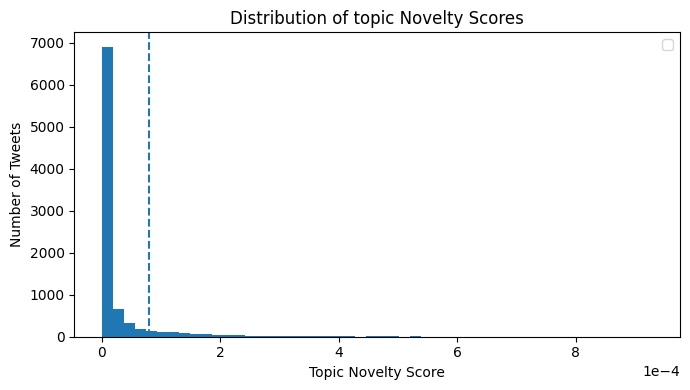

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(test_df['topic_novelty_score'], bins=50)
plt.axvline(threshold_topic, linestyle='--')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.title('Distribution of topic Novelty Scores')
plt.xlabel('Topic Novelty Score')
plt.ylabel('Number of Tweets')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
most_novel = test_df.sort_values('topic_novelty_score', ascending=False)

most_novel[['clean_date', 'Sentiment', 'clean_text', 'topic_novelty_score']].head(20)

,clean_date,Sentiment,clean_text,topic_novelty_score
19199,2009-06-19T23:03:28,negative,ok this is so not funny i stopped at walmart o...,0.000929
16926,2009-06-18T00:55:20,negative,configuring my new macbook pro unfortunately i...,0.000805
12438,2009-06-15T03:09:25,negative,just got home didnt tweet all day because my s...,0.000797
16927,2009-06-18T00:55:31,neutral,got most of my apps back on my ipod app data w...,0.000792
18831,2009-06-19T14:59:39,positive,i cant wait for my new iphone where the heck i...,0.000786
16388,2009-06-17T16:42:24,negative,mother effim at work till 11 and cant enjoy ip...,0.000706
12796,2009-06-15T08:36:52,neutral,i wonder why mac os x 106 will not have a blur...,0.000693
18792,2009-06-19T14:31:39,negative,atampt dunkirk ny does not sell iphones anymor...,0.000691
20484,2009-06-22T13:14:06,neutral,switching to ie until i figure out why ff keep...,0.000671
19557,2009-06-20T08:28:35,negative,its been 12 hours now and my 3gs still isnt ac...,0.000666


In [ ]:
print("Sentiment distribution among topic-novel tweets:")
novel_sentiment = test_df[test_df['is_topic_novel']]['Sentiment'].value_counts(normalize=True)
print(novel_sentiment)

print("\nSentiment distribution among all test tweets:")
overall_sentiment = test_df['Sentiment'].value_counts(normalize=True)
print(overall_sentiment)

sentiment_compare = pd.DataFrame({
    "Overall Tweets": overall_sentiment,
    "Novel Tweets": novel_sentiment
})

sentiment_compare

Sentiment distribution among topic-novel tweets:
Sentiment
negative    0.563677
neutral     0.270210
positive    0.166113
Name: proportion, dtype: float64

Sentiment distribution among all test tweets:
Sentiment
negative    0.506649
neutral     0.315935
positive    0.177416
Name: proportion, dtype: float64


,Overall Tweets,Novel Tweets
Sentiment,,
negative,0.506649,0.563677
neutral,0.315935,0.270210
positive,0.177416,0.166113


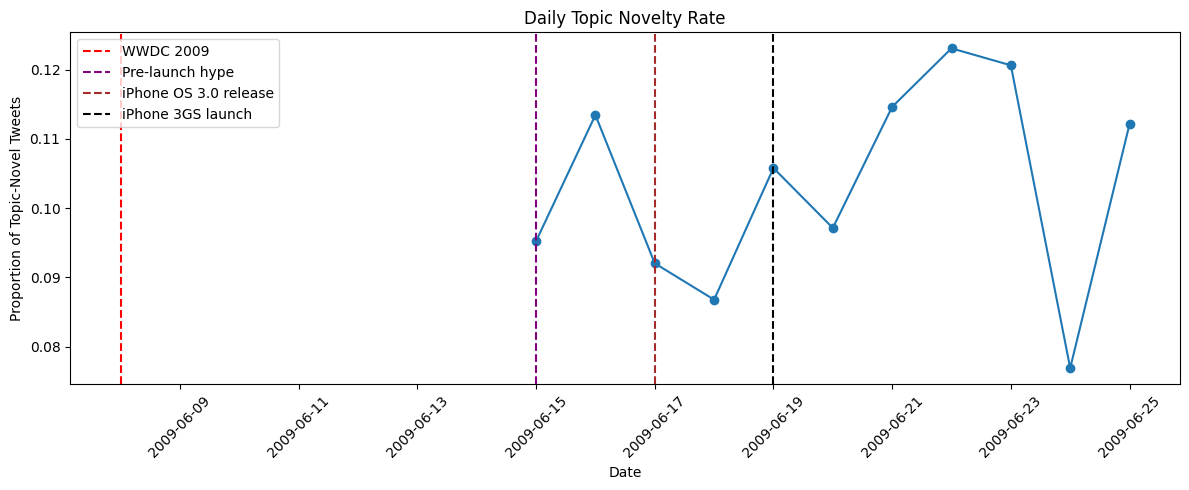

In [ ]:
test_df['clean_date'] = pd.to_datetime(test_df['clean_date'], errors='coerce')
test_df['date_only'] = test_df['clean_date'].dt.date

daily_novelty = test_df.groupby('date_only')['is_topic_novel'].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_novelty.index, daily_novelty.values, marker='o')

plt.axvline(pd.to_datetime("2009-06-08"), color='red', linestyle='--', label="WWDC 2009")
plt.axvline(pd.to_datetime("2009-06-15"), color='purple', linestyle='--', label="Pre-launch hype")
plt.axvline(pd.to_datetime("2009-06-17"), color='brown', linestyle='--', label="iPhone OS 3.0 release")
plt.axvline(pd.to_datetime("2009-06-19"), color='black', linestyle='--', label="iPhone 3GS launch")

plt.title("Daily Topic Novelty Rate")
plt.xlabel("Date")
plt.ylabel("Proportion of Topic-Novel Tweets")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
novel_df = test_df[test_df['is_topic_novel']].copy()

print("Novel tweet count:", len(novel_df))

Novel tweet count: 903


In [ ]:
novel_vectorizer = CountVectorizer(
    stop_words='english',
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)

novel_df['lemmatized_text'] = novel_df['clean_text'].apply(lemmatize_text)
X_novel = novel_vectorizer.fit_transform(novel_df['lemmatized_text'])

n_novel_topics = 3

lda_novel = LatentDirichletAllocation(
    n_components=n_novel_topics,
    random_state=42,
    learning_method='batch',
    max_iter=20
)

lda_novel.fit(X_novel)

LatentDirichletAllocation(max_iter=20, n_components=3, random_state=42)

In [ ]:
novel_feature_names = novel_vectorizer.get_feature_names_out()

print("Emerging Topics in Topic-Novel Tweets:")
print_topics(lda_novel, novel_feature_names, n_top_words=10)

Emerging Topics in Topic-Novel Tweets:
topic 1: ipod, iphone, itunes, 30, touch, new, ipod touch, 3g, wont, really
topic 2: iphone, just, im, mac, got, 3gs, machine, dont, tweetdeck, upgrade
topic 3: iphone, new, 30, update, day, new iphone, work, mac, im, today


In [ ]:
novel_topic_dist = lda_novel.transform(X_novel)
novel_df['emerging_topic'] = np.argmax(novel_topic_dist, axis=1) + 1

novel_df[['clean_date', 'Sentiment', 'clean_text', 'emerging_topic']].head(20)

,clean_date,Sentiment,clean_text,emerging_topic
12247,2009-06-15 00:02:23,positive,just received an email from one of my best fri...,1
12248,2009-06-15 00:02:25,positive,got a 15quot mac book pro at a student price w...,3
12252,2009-06-15 00:08:58,negative,f word i dont want to wait for the 3g ipod tou...,1
12272,2009-06-15 00:24:30,negative,oh no your poor iphone i cant imagine you with...,3
12277,2009-06-15 00:26:40,neutral,finally got my twitterific back on my iphone s...,2
12306,2009-06-15 01:00:24,neutral,still waiting for my squarespace iphone,3
12319,2009-06-15 01:14:19,neutral,i liked safari 4s tabsontop design better the ...,1
12326,2009-06-15 01:22:11,negative,me too unlimited data plan in 23 countries but...,3
12335,2009-06-15 01:31:06,positive,still some iphones top win on squarespace,3
12353,2009-06-15 01:46:29,negative,im abit worried about it apple store is miles ...,2


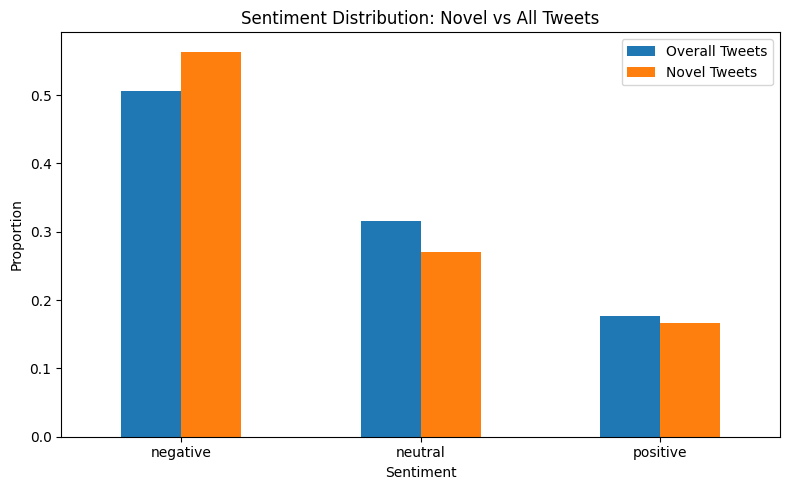

In [ ]:
sentiment_compare.plot(kind='bar', figsize=(8,5))

plt.title("Sentiment Distribution: Novel vs All Tweets")
plt.ylabel("Proportion")
plt.xlabel("Sentiment")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
novelty_rate = test_df.groupby('Sentiment')['is_topic_novel'].mean()

print("Novelty rate by sentiment:")
print(novelty_rate)

Novelty rate by sentiment:
Sentiment
negative    0.111330
neutral     0.085584
positive    0.093691
Name: is_topic_novel, dtype: float64


### **BertTopic**

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 16.6 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import plotly.io as pio
pio.renderers.default = "colab" #so that plotly renders inline in colab

In [ ]:
# ── CELL: Prepare documents ──────────────────────────────────
# Running BERTopic on the same novel tweets used for LDA
# so the comparison is fair.
docs = novel_df['clean_text'].tolist()
print(f"Running BERTopic on {len(docs)} topic-novel tweets")

Running BERTopic on 903 topic-novel tweets


In [ ]:
# ── CELL: Configure BERTopic components ──────────────────────
# Each sub-model is set explicitly to understand every moving part:
# 1. Embedding model – converts tweets to semantic vectors
embedding_model = SentenceTransformer("all-mpnet-base-v2")
# "all-MiniLM-L6-v2" is fast and works well on short social-media text.
# Can Swap for "all-mpnet-base-v2" if you want higher quality at the cost of speed.

# 2. UMAP – reduces 384-dim embeddings to a lower-dim space for clustering
umap_model = UMAP(n_neighbors=5, # low value works better for small corpora (<1000 docs)
                  n_components=5, # dimensions fed into HDBSCAN
                  min_dist=0.0, #tighter cluster
                  metric="cosine",
                  random_state=42)

# 3. HDBSCAN – density-based clustering; noise points → topic -1
hdbscan_model = HDBSCAN(min_cluster_size=12, #minimum tweets per topic
                        min_samples=3,
                        metric='euclidean',
                        cluster_selection_method="eom",
                        prediction_data=True #needed for soft cluster assignmnet below
                        )

# 4. CountVectorizer for BERTopic's c-TF-IDF topic representation
# (note: this is different from your TF-IDF vectoriser above)
vectorizer_model = CountVectorizer(stop_words="english",
                                   ngram_range=(1, 2),
                                   min_df=2)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# ── CELL: Fit BERTopic ───────────────────────────────────────
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)
print(f"\nTopics found (excl. noise topic -1): "
      f"{len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"Noise tweets (topic -1): {topics.count(-1)}")

2026-05-04 13:05:54,785 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

2026-05-04 13:05:58,065 - BERTopic - Embedding - Completed ✓
2026-05-04 13:05:58,067 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 13:06:14,016 - BERTopic - Dimensionality - Completed ✓
2026-05-04 13:06:14,017 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 13:06:14,054 - BERTopic - Cluster - Completed ✓
2026-05-04 13:06:14,059 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 13:06:14,116 - BERTopic - Representation - Completed ✓



Topics found (excl. noise topic -1): 18
Noise tweets (topic -1): 89


In [ ]:
# ── CELL: Topic overview ─────────────────────────────────────
print("=" * 60)
print("BERTopic – Emerging Topics in Novel Tweets")
print("=" * 60)
topic_info = topic_model.get_topic_info()
print(topic_info.to_string(index=False))

BERTopic – Emerging Topics in Novel Tweets
 Topic  Count                                   Name                                                                                                  Representation                                                                                                                                                                                                                                                                                                                                                       Representative_Docs
    -1     89               -1_30_iphone_server_ipod                                               [30, iphone, server, ipod, video, cut, paste, new, itunes, touch]                                                                 [got that new iphone 3g s for the people that dont know u cant mms message yet but the video camera is awesome, no but the iphone 30 upgrade seems to have cut my 3g data connection, is the prob fixed a

In [ ]:
# ── CELL: Top words per topic ────────────────────────────────
for tid in sorted(set(topics)):
  if tid == -1:
    continue
  words = [w for w, _ in topic_model.get_topic(tid)]
  print(f"Topic {tid:>2}: {', '.join(words)}")

Topic  0: mac, macbook, machine, pro, imac, apple, just, macbook pro, need, think
Topic  1: iphone, new, im, blackberry, want, phone, just, wish, iphones, old
Topic  2: new iphone, iphone, wait, new, early, sleep, day, got, work, tomorrow
Topic  3: 3g, 3gs, iphone, iphone 3g, upgrade, iphone 3gs, mms, lvatt, want, dont
Topic  4: itunes, ipod, miss, music, sync, dont, songs, album, hope, work
Topic  5: update, iphone update, updating, iphone, update iphone, mobileme, updating iphone, store, phone, itunes store
Topic  6: 30, os 30, os, iphone os, upgrade, ipod, ipod touch, touch, upgrade 30, 30 upgrade
Topic  7: twitter, tweet, twitterific, working, app, stupid iphone, tweetie, stupid, iphone, finally
Topic  8: itunes, songs, ipod, stupid, watching, bed, help, bored, time, just
Topic  9: squarespace, win, card, iphone, soo, trackle, long, line new, device, 100
Topic 10: jailbreak, 30, apps, able, download, development, iphone development, 30 ipod, wont able, waiting
Topic 11: tweetdeck, 

In [ ]:
# ── CELL: Assign BERTopic labels back to novel_df ────────────
novel_df = novel_df.copy()
novel_df['bertopic_label'] = topics
novel_df['bertopic_prob']  = probs if probs.ndim == 1 else probs.max(axis=1)

print("Topic assignment distribution (incl. noise = -1):")
print(novel_df['bertopic_label'].value_counts())

Topic assignment distribution (incl. noise = -1):
bertopic_label
 0     174
 1     115
-1      89
 2      77
 3      72
 4      60
 5      46
 6      32
 7      29
 8      28
 9      27
 10     26
 11     25
 12     22
 13     19
 14     17
 15     16
 16     16
 17     13
Name: count, dtype: int64


In [ ]:
# ── CELL: Sentiment breakdown per BERTopic topic ─────────────
# Are some emerging topics systematically more negative?
bert_sentiment = (
    novel_df[novel_df['bertopic_label'] != -1]          # exclude noise
    .groupby(['bertopic_label', 'Sentiment'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)               # proportions
)
print("Sentiment distribution per BERTopic topic (row-normalised):")
print(bert_sentiment.round(3))

Sentiment distribution per BERTopic topic (row-normalised):
Sentiment       negative  neutral  positive
bertopic_label                             
0                  0.534    0.287     0.178
1                  0.530    0.270     0.200
2                  0.416    0.299     0.286
3                  0.597    0.264     0.139
4                  0.717    0.217     0.067
5                  0.696    0.239     0.065
6                  0.781    0.156     0.062
7                  0.655    0.103     0.241
8                  0.500    0.286     0.214
9                  0.444    0.407     0.148
10                 0.692    0.269     0.038
11                 0.440    0.320     0.240
12                 0.545    0.182     0.273
13                 0.737    0.263     0.000
14                 0.412    0.529     0.059
15                 0.688    0.125     0.188
16                 0.125    0.562     0.312
17                 0.769    0.154     0.077


In [ ]:
# ── CELL: Visualise – topic bar chart ────────────────────────
fig_bar = topic_model.visualize_barchart(top_n_topics=8, n_words=8)
fig_bar.show()

In [ ]:
# ── CELL: Visualise – 2-D topic map ──────────────────────────
fig_topics = topic_model.visualize_topics()
fig_topics.show()

In [ ]:
# ── CELL: Visualise – documents coloured by topic ────────────
# This embeds the tweets in 2-D and colours them by cluster.
fig_docs = topic_model.visualize_documents(
    docs,
    topics=topics,
    hide_annotations=True,      # cleaner for large corpora
    hide_document_hover=False
)
fig_docs.show()

In [ ]:
# ── CELL: LDA vs BERTopic comparison ─────────────────────────
# Map each tweet's LDA dominant topic alongside BERTopic label.
# (novel_df already has 'emerging_topic' from LDA above)

comparison = novel_df[['clean_date', 'Sentiment', 'clean_text',
                        'emerging_topic', 'bertopic_label']].copy()
comparison.columns = ['date', 'sentiment', 'text',
                      'lda_topic', 'bertopic_topic']

print("LDA vs BERTopic topic assignments (first 20 rows):")
print(comparison.head(20).to_string(index=False))

# Cross-tabulation: how much do the two models agree on groupings?
cross_tab = pd.crosstab(
    comparison['lda_topic'],
    comparison['bertopic_topic'],
    margins=True
)
print("\nCross-tabulation  (rows = LDA topic, cols = BERTopic topic):")
print(cross_tab)

LDA vs BERTopic topic assignments (first 20 rows):
               date sentiment                                                                                                                                  text  lda_topic  bertopic_topic
2009-06-15 00:02:23  positive                            just received an email from one of my best friends in us hell try to get me the new iphonebless his soul x          1               1
2009-06-15 00:02:25  positive                                      got a 15quot mac book pro at a student price with free wireless mighty mouse and display adapter          3               0
2009-06-15 00:08:58  negative                      f word i dont want to wait for the 3g ipod touch to come out in september i want to get it now but ill regret it          1               3
2009-06-15 00:24:30  negative                                                     oh no your poor iphone i cant imagine you without it send me your new number asap          3           

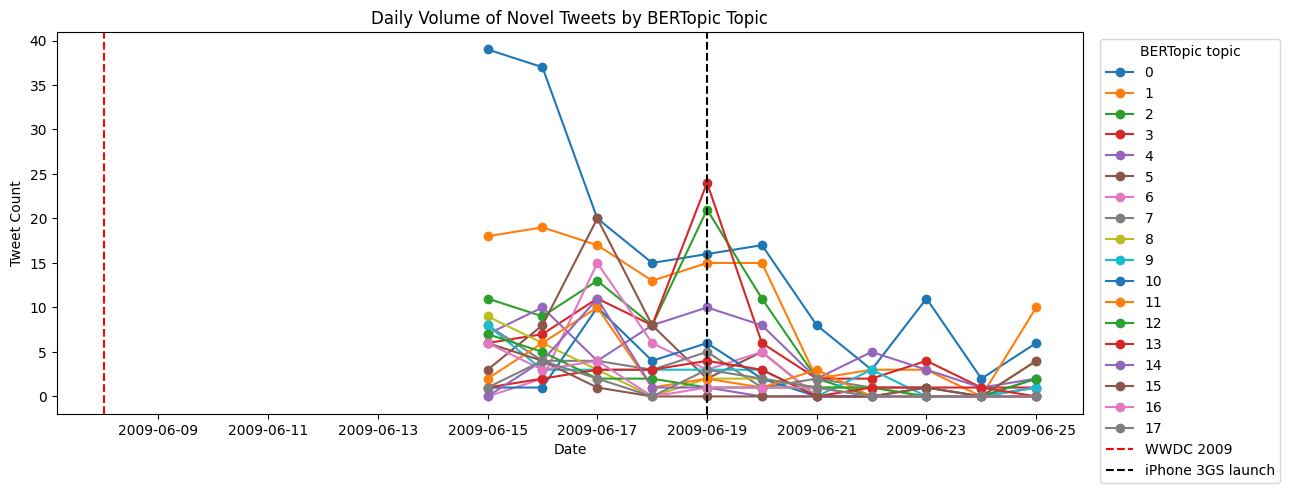

In [ ]:
# ── CELL: Daily BERTopic novelty timeline ────────────────────
# Same as your LDA novelty timeline but now broken down by BERTopic topic.
novel_df['date_only'] = pd.to_datetime(novel_df['clean_date'], errors='coerce').dt.date

# Count tweets per day per BERTopic topic (excl. noise)
bert_daily = (
    novel_df[novel_df['bertopic_label'] != -1]
    .groupby(['date_only', 'bertopic_label'])
    .size()
    .unstack(fill_value=0)
)

bert_daily.plot(figsize=(13, 5), marker='o')

plt.axvline(pd.to_datetime("2009-06-08").date(), color='red',
            linestyle='--', label="WWDC 2009")
plt.axvline(pd.to_datetime("2009-06-19").date(), color='black',
            linestyle='--', label="iPhone 3GS launch")

plt.title("Daily Volume of Novel Tweets by BERTopic Topic")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.legend(title="BERTopic topic", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL: Per-topic novelty scores ───────────────────────────
# Embed the training tweets once
train_docs = train_df['clean_text'].tolist()
train_embeddings = embedding_model.encode(train_docs, batch_size=64, show_progress_bar=True)

# Get BERTopic's own embeddings for the novel tweets
novel_embeddings = embedding_model.encode(docs, batch_size=64, show_progress_bar=True)

# Compute centroid per topic and compare to training data
print("Topic Novelty Scores (higher = more novel vs training corpus)")
print("=" * 65)

topic_novelty = {}
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    # Average embedding of all tweets in this topic
    idx = [i for i, t in enumerate(topics) if t == tid]
    centroid = novel_embeddings[idx].mean(axis=0)

    # Max cosine similarity to any training tweet
    sims = cosine_similarity([centroid], train_embeddings)
    novelty_score = 1 - sims.max()
    topic_novelty[tid] = novelty_score

    words = [w for w, _ in topic_model.get_topic(tid)][:5]
    print(f"  Topic {tid+1:>2} ({', '.join(words)}): {novelty_score:.4f}")

# Rank topics from most to least novel
print("\nRanked by novelty (most novel first):")
for tid, score in sorted(topic_novelty.items(), key=lambda x: -x[1]):
    words = [w for w, _ in topic_model.get_topic(tid)][:5]
    print(f"  Topic {tid+1:>2}: {score:.4f}  |  {', '.join(words)}")

Batches:   0%|          | 0/192 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Topic Novelty Scores (higher = more novel vs training corpus)
  Topic  1 (mac, macbook, machine, pro, imac): 0.2215
  Topic  2 (iphone, new, im, blackberry, want): 0.1961
  Topic  3 (new iphone, iphone, wait, new, early): 0.2059
  Topic  4 (3g, 3gs, iphone, iphone 3g, upgrade): 0.2145
  Topic  5 (itunes, ipod, miss, music, sync): 0.1739
  Topic  6 (update, iphone update, updating, iphone, update iphone): 0.2369
  Topic  7 (30, os 30, os, iphone os, upgrade): 0.1689
  Topic  8 (twitter, tweet, twitterific, working, app): 0.1737
  Topic  9 (itunes, songs, ipod, stupid, watching): 0.2465
  Topic 10 (squarespace, win, card, iphone, soo): 0.2434
  Topic 11 (jailbreak, 30, apps, able, download): 0.1991
  Topic 12 (tweetdeck, desktop, iphone, app, amp): 0.1641
  Topic 13 (pharmacy, help, headache, sitting, fml): 0.3103
  Topic 14 (ipod, aka, stopped, gt, mode): 0.1643
  Topic 15 (30, iphone 30, update, 30 update, iphone os): 0.1659
  Topic 16 (safari, chrome, google, google chrome, firefox): 

## **Comparison**

In [ ]:
# ── CELL: Embed training tweets ───────────────────────────────
train_docs = train_df['clean_text'].tolist()
print(f"Embedding {len(train_docs)} training tweets...")
train_embeddings = embedding_model.encode(train_docs, batch_size=64, show_progress_bar=True)
print("Done!")

Embedding 12245 training tweets...


Batches:   0%|          | 0/192 [00:00<?, ?it/s]

Done!


In [ ]:
# ── CELL: Embed novel tweets & compute topic centroids ────────
novel_embeddings = embedding_model.encode(docs, batch_size=64, show_progress_bar=True)

# Compute centroid (average embedding) for each BERTopic topic
topic_centroids = {}
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    idx = [i for i, t in enumerate(topics) if t == tid]
    topic_centroids[tid] = novel_embeddings[idx].mean(axis=0)

print(f"Computed centroids for {len(topic_centroids)} topics")

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Computed centroids for 18 topics


In [ ]:
# ── CELL: Compare each topic centroid to ALL training tweets ──
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Topic Novelty Analysis")
print("=" * 70)
print(f"{'Topic':<10} {'Top Words':<40} {'Max Sim':>8} {'Novelty':>8}")
print("-" * 70)

topic_novelty_results = []

for tid in sorted(topic_centroids.keys()):
    centroid  = topic_centroids[tid]

    # Similarity between this topic centroid and every training tweet
    sims      = cosine_similarity([centroid], train_embeddings)[0]
    max_sim   = sims.max()         # closest training tweet
    novelty   = 1 - max_sim        # how far from anything in training

    words = [w for w, _ in topic_model.get_topic(tid)][:5]
    topic_novelty_results.append({
        'topic_id':    tid,
        'top_words':   ', '.join(words),
        'max_sim':     round(max_sim, 4),
        'novelty':     round(novelty, 4)
    })

    print(f"Topic {tid+1:<4}  {', '.join(words):<40} {max_sim:>8.4f} {novelty:>8.4f}")

# Convert to df for easy sorting
novelty_df = pd.DataFrame(topic_novelty_results)

Topic Novelty Analysis
Topic      Top Words                                 Max Sim  Novelty
----------------------------------------------------------------------
Topic 1     mac, macbook, machine, pro, imac           0.7785   0.2215
Topic 2     iphone, new, im, blackberry, want          0.8039   0.1961
Topic 3     new iphone, iphone, wait, new, early       0.7941   0.2059
Topic 4     3g, 3gs, iphone, iphone 3g, upgrade        0.7855   0.2145
Topic 5     itunes, ipod, miss, music, sync            0.8261   0.1739
Topic 6     update, iphone update, updating, iphone, update iphone   0.7631   0.2369
Topic 7     30, os 30, os, iphone os, upgrade          0.8311   0.1689
Topic 8     twitter, tweet, twitterific, working, app   0.8263   0.1737
Topic 9     itunes, songs, ipod, stupid, watching      0.7535   0.2465
Topic 10    squarespace, win, card, iphone, soo        0.7566   0.2434
Topic 11    jailbreak, 30, apps, able, download        0.8009   0.1991
Topic 12    tweetdeck, desktop, iphone, 

In [ ]:
# ── CELL: Rank topics from most to least novel ────────────────
print("\nTopics ranked by novelty (most novel first):")
print("=" * 70)

ranked = novelty_df.sort_values('novelty', ascending=False).reset_index(drop=True)

for _, row in ranked.iterrows():
    label = "★ NOVEL"    if row['novelty'] > 0.5 else \
            "~ BORDERLINE" if row['novelty'] > 0.3 else \
            "✗ RECURRING"
    print(f"  {label:<14} Topic {int(row['topic_id'])+1}: "
          f"{row['top_words']:<40} (novelty={row['novelty']:.4f})")


Topics ranked by novelty (most novel first):
  ~ BORDERLINE   Topic 13: pharmacy, help, headache, sitting, fml   (novelty=0.3103)
  ✗ RECURRING    Topic 17: itunes, ipod, vid, uk, music             (novelty=0.2768)
  ✗ RECURRING    Topic 9: itunes, songs, ipod, stupid, watching    (novelty=0.2465)
  ✗ RECURRING    Topic 10: squarespace, win, card, iphone, soo      (novelty=0.2434)
  ✗ RECURRING    Topic 6: update, iphone update, updating, iphone, update iphone (novelty=0.2369)
  ✗ RECURRING    Topic 1: mac, macbook, machine, pro, imac         (novelty=0.2215)
  ✗ RECURRING    Topic 4: 3g, 3gs, iphone, iphone 3g, upgrade      (novelty=0.2145)
  ✗ RECURRING    Topic 3: new iphone, iphone, wait, new, early     (novelty=0.2059)
  ✗ RECURRING    Topic 11: jailbreak, 30, apps, able, download      (novelty=0.1991)
  ✗ RECURRING    Topic 2: iphone, new, im, blackberry, want        (novelty=0.1961)
  ✗ RECURRING    Topic 5: itunes, ipod, miss, music, sync          (novelty=0.1739)
  ✗ RECURRIN

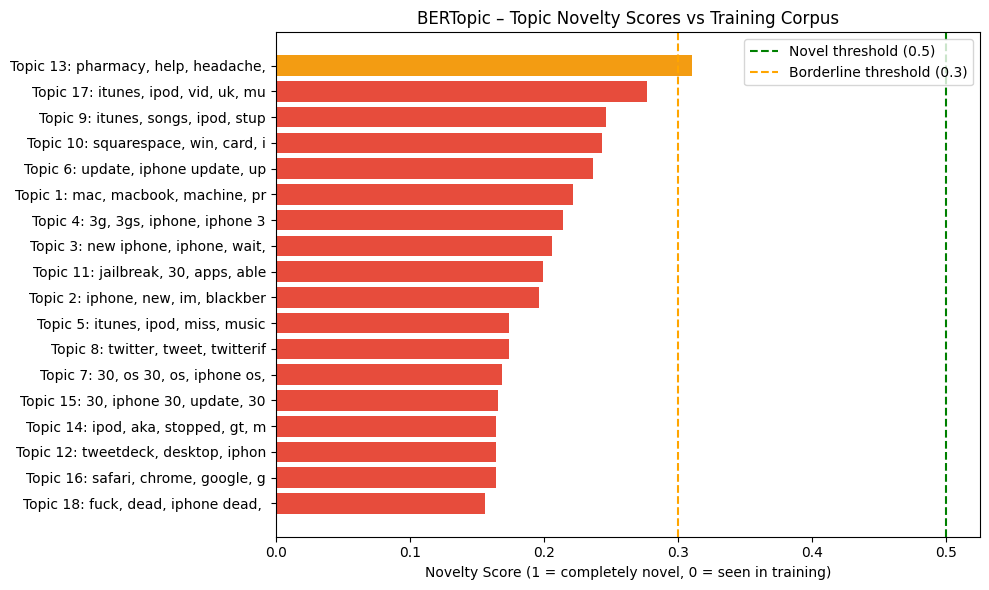

In [ ]:
# ── CELL: Visualise topic novelty scores ─────────────────────
ranked_plot = novelty_df.sort_values('novelty', ascending=True)

colors = ['#2ecc71' if n > 0.5 else '#f39c12' if n > 0.3 else '#e74c3c'
          for n in ranked_plot['novelty']]

plt.figure(figsize=(10, 6))
plt.barh(
    [f"Topic {int(t)+1}: {w[:25]}" for t, w in
     zip(ranked_plot['topic_id'], ranked_plot['top_words'])],
    ranked_plot['novelty'],
    color=colors
)
plt.axvline(0.5, linestyle='--', color='green',  label='Novel threshold (0.5)')
plt.axvline(0.3, linestyle='--', color='orange', label='Borderline threshold (0.3)')
plt.title("BERTopic – Topic Novelty Scores vs Training Corpus")
plt.xlabel("Novelty Score (1 = completely novel, 0 = seen in training)")
plt.legend()
plt.tight_layout()
plt.show()

## **Comparing Training Topic Centriods Not Individual Tweets**

In [ ]:
# ── CELL: Run BERTopic on training data too ──────────────────
print(f"Fitting BERTopic on {len(train_docs)} training tweets...")

train_topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=make_umap() if 'make_umap' in dir() else UMAP(
        n_neighbors=5, n_components=5, min_dist=0.0,
        metric="cosine", random_state=42),
    hdbscan_model=HDBSCAN(
        min_cluster_size=12, min_samples=3,
        metric="euclidean", cluster_selection_method="eom",
        prediction_data=True),
    vectorizer_model=CountVectorizer(
        stop_words="english", ngram_range=(1,2), min_df=2),
    top_n_words=10,
    verbose=False
)

train_topics_list, _ = train_topic_model.fit_transform(train_docs)

n_train_topics = len(set(train_topics_list)) - (1 if -1 in train_topics_list else 0)
print(f"Training topics found: {n_train_topics}")

print("\nTraining Topics (what existed BEFORE June 15):")
for tid in sorted(set(train_topics_list)):
    if tid == -1:
        continue
    words = [w for w, _ in train_topic_model.get_topic(tid)][:6]
    print(f"  Topic {tid+1}: {', '.join(words)}")

Fitting BERTopic on 12245 training tweets...
Training topics found: 262

Training Topics (what existed BEFORE June 15):
  Topic 1: twitter, tweet, twitterfon, tweeting, tweets, twitterific
  Topic 2: wwdc, keynote, e3, steve, steve jobs, wwdc tomorrow
  Topic 3: safari, firefox, ff, beta, browser, use safari
  Topic 4: stomachache, stomache, headache, stomache hurts, hurts, ache
  Topic 5: listening, listening ipod, watching, tv, watch, bed
  Topic 6: macbook, pro, want, want macbook, dell, macbook pro
  Topic 7: ipod touch, touch, new ipod, got ipod, itunes gift, ipod
  Topic 8: smack, smacked, smacks, smacking, face, talk
  Topic 9: forgot ipod, forgot, left ipod, headphones, ipod headphones, ipod home
  Topic 10: apple store, store, apple, store apple, apple stores, im apple
  Topic 11: podcasts, podcast, podcast itunes, listen podcasts, listen, loved
  Topic 12: big mac, maccas, eating, eat, big, fries
  Topic 13: sleep, bed, tired, im tired, bedtime, fall
  Topic 14: itunes, music

In [ ]:
# ── CELL: Compute training topic centroids ────────────────────
train_embeddings_array = np.array(train_embeddings)

train_topic_centroids = {}
for tid in sorted(set(train_topics_list)):
    if tid == -1:
        continue
    idx = [i for i, t in enumerate(train_topics_list) if t == tid]
    train_topic_centroids[tid] = train_embeddings_array[idx].mean(axis=0)

print(f"Computed {len(train_topic_centroids)} training topic centroids")

Computed 262 training topic centroids


In [ ]:
# ── CELL: Compare novel topic centroids vs training topic centroids ──
print("Topic Novelty Analysis (vs Training Topic Centroids)")
print("=" * 75)
print(f"{'Topic':<10} {'Top Words':<35} {'Max Sim':>8} {'Novelty':>8} {'Closest Train Topic'}")
print("-" * 75)

topic_novelty_results2 = []

train_centroid_matrix = np.array(list(train_topic_centroids.values()))
train_centroid_ids    = list(train_topic_centroids.keys())

for tid in sorted(topic_centroids.keys()):
    centroid = topic_centroids[tid]

    # Compare against training topic centroids (not individual tweets)
    sims     = cosine_similarity([centroid], train_centroid_matrix)[0]
    max_sim  = sims.max()
    novelty  = 1 - max_sim

    # Which training topic is it closest to?
    closest_train_tid   = train_centroid_ids[sims.argmax()]
    closest_train_words = [w for w, _ in train_topic_model.get_topic(closest_train_tid)][:4]

    novel_words = [w for w, _ in topic_model.get_topic(tid)][:5]

    topic_novelty_results2.append({
        'topic_id':          tid,
        'top_words':         ', '.join(novel_words),
        'max_sim':           round(max_sim, 4),
        'novelty':           round(novelty, 4),
        'closest_train':     ', '.join(closest_train_words)
    })

    print(f"Topic {tid+1:<4}  {', '.join(novel_words):<35} "
          f"{max_sim:>8.4f} {novelty:>8.4f}  ← {', '.join(closest_train_words)}")

novelty_df2 = pd.DataFrame(topic_novelty_results2)

Topic Novelty Analysis (vs Training Topic Centroids)
Topic      Top Words                            Max Sim  Novelty Closest Train Topic
---------------------------------------------------------------------------
Topic 1     mac, macbook, machine, pro, imac      0.8861   0.1139  ← math, miss mac, exams, mac left
Topic 2     iphone, new, im, blackberry, want     0.9070   0.0930  ← having iphone, hee, need iphone, iphone lol
Topic 3     new iphone, iphone, wait, new, early   0.8804   0.1196  ← swine flu, swine, flu, tomorrow iphone
Topic 4     3g, 3gs, iphone, iphone 3g, upgrade   0.8944   0.1056  ← new iphone, wait new, wait, 3g
Topic 5     itunes, ipod, miss, music, sync       0.8776   0.1224  ← thing happened, music, happened, replaced
Topic 6     update, iphone update, updating, iphone, update iphone   0.8085   0.1915  ← 30, iphone 30, os 30, 30 beta
Topic 7     30, os 30, os, iphone os, upgrade     0.8690   0.1310  ← 30, iphone 30, os 30, 30 beta
Topic 8     twitter, tweet, twitter

In [ ]:
# ── CELL: Ranked results ──────────────────────────────────────
print("\nTopics ranked by novelty (most novel first):")
print("=" * 75)

ranked2 = novelty_df2.sort_values('novelty', ascending=False).reset_index(drop=True)

for _, row in ranked2.iterrows():
    label = "★ NOVEL"       if row['novelty'] > 0.5 else \
            "~ BORDERLINE"  if row['novelty'] > 0.3 else \
            "✗ RECURRING"
    print(f"  {label:<14} Topic {int(row['topic_id'])+1}: "
          f"{row['top_words']:<35} novelty={row['novelty']:.4f} "
          f"| closest: {row['closest_train']}")


Topics ranked by novelty (most novel first):
  ✗ RECURRING    Topic 13: pharmacy, help, headache, sitting, fml novelty=0.2375 | closest: stomachache, stomache, headache, stomache hurts
  ✗ RECURRING    Topic 10: squarespace, win, card, iphone, soo novelty=0.2163 | closest: giveaway, iphone promocodes, promocodes, tomorrow iphone
  ✗ RECURRING    Topic 6: update, iphone update, updating, iphone, update iphone novelty=0.1915 | closest: 30, iphone 30, os 30, 30 beta
  ✗ RECURRING    Topic 11: jailbreak, 30, apps, able, download novelty=0.1763 | closest: 30, iphone 30, os 30, 30 beta
  ✗ RECURRING    Topic 12: tweetdeck, desktop, iphone, app, amp novelty=0.1706 | closest: twitter, tweet, twitterfon, tweeting
  ✗ RECURRING    Topic 15: 30, iphone 30, update, 30 update, iphone os novelty=0.1662 | closest: 30, iphone 30, os 30, 30 beta
  ✗ RECURRING    Topic 17: itunes, ipod, vid, uk, music        novelty=0.1568 | closest: tha, download ipod, video isnt, amazon
  ✗ RECURRING    Topic 7: 30, 

# **No Novelty I Guess**

In [ ]:
# ── CELL: Map ALL test and train tweets to BERTopic topics ────
# (not just novel tweets — all of them)

print("Transforming all training tweets...")
all_train_topics, _ = topic_model.transform(train_df['clean_text'].tolist())

print("Transforming all test tweets...")
all_test_topics, _  = topic_model.transform(test_df['clean_text'].tolist())

train_df['bertopic_label'] = all_train_topics
test_df['bertopic_label']  = all_test_topics

Transforming all training tweets...


Batches:   0%|          | 0/383 [00:00<?, ?it/s]

Transforming all test tweets...


Batches:   0%|          | 0/282 [00:00<?, ?it/s]

In [ ]:
# ── CELL: Count tweets per topic in train vs test ─────────────

train_counts = (train_df[train_df['bertopic_label'] != -1]
                ['bertopic_label'].value_counts()
                .rename('train_count'))

test_counts  = (test_df[test_df['bertopic_label'] != -1]
                ['bertopic_label'].value_counts()
                .rename('test_count'))

# Combine into one df
topic_comparison = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)

# Add top words for readability
topic_comparison['top_words'] = topic_comparison.index.map(
    lambda tid: ', '.join([w for w, _ in topic_model.get_topic(tid)][:5])
    if tid != -1 else 'noise'
)

# Total tweets and test share
topic_comparison['total']      = topic_comparison['train_count'] + topic_comparison['test_count']
topic_comparison['test_share'] = (topic_comparison['test_count'] /
                                   topic_comparison['total'] * 100).round(1)

# Sort by total size — biggest topics first
topic_comparison = topic_comparison.sort_values('total', ascending=False)

print("Topic sizes — Train vs Test")
print("=" * 75)
print(f"{'Topic':<10} {'Train':>8} {'Test':>8} {'Total':>8} {'Test%':>7}  Top Words")
print("-" * 75)
for tid, row in topic_comparison.iterrows():
    flag = " ▲ GREW" if row['test_share'] > 60 else ""
    print(f"Topic {tid+1:<4}  {row['train_count']:>8} {row['test_count']:>8} "
          f"{row['total']:>8} {row['test_share']:>6.1f}%  {row['top_words']}{flag}")

Topic sizes — Train vs Test
Topic         Train     Test    Total   Test%  Top Words
---------------------------------------------------------------------------
Topic 1         3444     1419     4863   29.2%  mac, macbook, machine, pro, imac
Topic 2         1301     1017     2318   43.9%  iphone, new, im, blackberry, want
Topic 3          621      682     1303   52.3%  new iphone, iphone, wait, new, early
Topic 4          213      798     1011   78.9%  3g, 3gs, iphone, iphone 3g, upgrade ▲ GREW
Topic 5          510      445      955   46.6%  itunes, ipod, miss, music, sync
Topic 13         619      263      882   29.8%  pharmacy, help, headache, sitting, fml
Topic 9          621      225      846   26.6%  itunes, songs, ipod, stupid, watching
Topic 14         487      300      787   38.1%  ipod, aka, stopped, gt, mode
Topic 8          428      246      674   36.5%  twitter, tweet, twitterific, working, app
Topic 12         276      279      555   50.3%  tweetdeck, desktop, iphone, app,

In [ ]:
# ── CELL: Overlapping topics — sentiment breakdown ────────────
# For topics that exist in both train and test,
# compare sentiment distribution

# Only keep topics that appear in both
overlapping = topic_comparison[
    (topic_comparison['train_count'] > 0) &
    (topic_comparison['test_count']  > 0)
].index.tolist()

print("Sentiment breakdown for overlapping topics")
print("=" * 75)

results = []

for tid in overlapping:
    train_tweets = train_df[train_df['bertopic_label'] == tid]
    test_tweets  = test_df[test_df['bertopic_label']  == tid]

    train_sent = train_tweets['Sentiment'].value_counts(normalize=True).round(3)
    test_sent  = test_tweets['Sentiment'].value_counts(normalize=True).round(3)

    words = ', '.join([w for w, _ in topic_model.get_topic(tid)][:5])

    print(f"\nTopic {tid+1}: {words}")
    print(f"  Train ({len(train_tweets)} tweets): "
          f"neg={train_sent.get('negative',0):.2f}  "
          f"neu={train_sent.get('neutral',0):.2f}  "
          f"pos={train_sent.get('positive',0):.2f}")
    print(f"  Test  ({len(test_tweets)} tweets):  "
          f"neg={test_sent.get('negative',0):.2f}  "
          f"neu={test_sent.get('neutral',0):.2f}  "
          f"pos={test_sent.get('positive',0):.2f}")

    # Flag if test set is larger or sentiment shifted significantly
    size_flag     = " ▲ TEST LARGER"   if len(test_tweets) > len(train_tweets) else ""
    neg_shift     = test_sent.get('negative',0) - train_sent.get('negative',0)
    sentiment_flag = f" ← sentiment shift: neg {'▲' if neg_shift > 0.05 else '▼'} {abs(neg_shift):.2f}" \
                     if abs(neg_shift) > 0.05 else ""

    if size_flag or sentiment_flag:
        print(f"  ⚑ {size_flag}{sentiment_flag}")

    results.append({
        'topic_id':        tid,
        'top_words':       words,
        'train_count':     len(train_tweets),
        'test_count':      len(test_tweets),
        'train_neg':       train_sent.get('negative', 0),
        'test_neg':        test_sent.get('negative',  0),
        'neg_shift':       round(neg_shift, 3)
    })

overlap_df = pd.DataFrame(results)

Sentiment breakdown for overlapping topics

Topic 1: mac, macbook, machine, pro, imac
  Train (3444 tweets): neg=0.33  neu=0.35  pos=0.31
  Test  (1419 tweets):  neg=0.49  neu=0.32  pos=0.20
  ⚑  ← sentiment shift: neg ▲ 0.15

Topic 2: iphone, new, im, blackberry, want
  Train (1301 tweets): neg=0.30  neu=0.37  pos=0.33
  Test  (1017 tweets):  neg=0.43  neu=0.31  pos=0.27
  ⚑  ← sentiment shift: neg ▲ 0.12

Topic 3: new iphone, iphone, wait, new, early
  Train (621 tweets): neg=0.25  neu=0.31  pos=0.44
  Test  (682 tweets):  neg=0.44  neu=0.33  pos=0.23
  ⚑  ▲ TEST LARGER ← sentiment shift: neg ▲ 0.19

Topic 4: 3g, 3gs, iphone, iphone 3g, upgrade
  Train (213 tweets): neg=0.32  neu=0.35  pos=0.32
  Test  (798 tweets):  neg=0.48  neu=0.35  pos=0.17
  ⚑  ▲ TEST LARGER ← sentiment shift: neg ▲ 0.15

Topic 5: itunes, ipod, miss, music, sync
  Train (510 tweets): neg=0.57  neu=0.30  pos=0.13
  Test  (445 tweets):  neg=0.63  neu=0.28  pos=0.09
  ⚑  ← sentiment shift: neg ▲ 0.06

Topic 13: ph

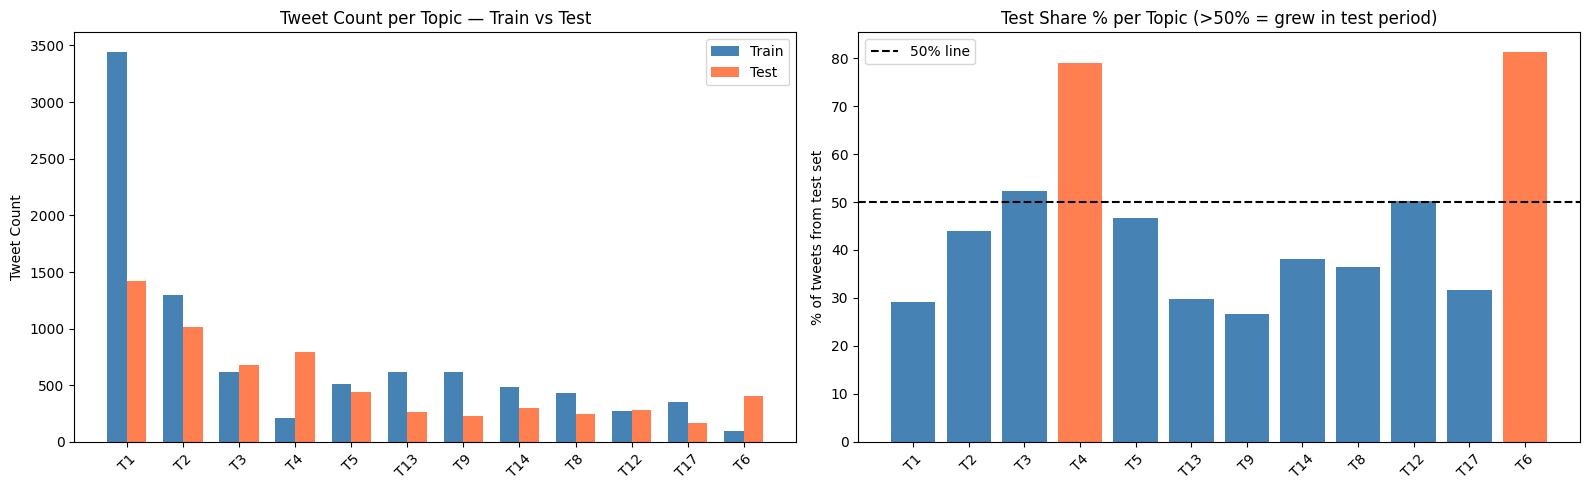

In [ ]:
# ── CELL: Visualise — train vs test tweet counts per topic ────
top_topics = topic_comparison.head(12)  # top 12 biggest topics

x      = range(len(top_topics))
width  = 0.35
labels = [f"T{tid+1}" for tid in top_topics.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw counts
axes[0].bar([i - width/2 for i in x], top_topics['train_count'],
            width, label='Train', color='steelblue')
axes[0].bar([i + width/2 for i in x], top_topics['test_count'],
            width, label='Test',  color='coral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_title("Tweet Count per Topic — Train vs Test")
axes[0].set_ylabel("Tweet Count")
axes[0].legend()

# Right: test share %
axes[1].bar(labels, top_topics['test_share'], color=[
    'coral' if v > 60 else 'steelblue' for v in top_topics['test_share']
])
axes[1].axhline(50, linestyle='--', color='black', label='50% line')
axes[1].set_title("Test Share % per Topic (>50% = grew in test period)")
axes[1].set_ylabel("% of tweets from test set")
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── CELL: Sentiment shift visualisation ──────────────────────
# For topics where test set is bigger, show sentiment comparison

grew = overlap_df[overlap_df['test_count'] > overlap_df['train_count']].copy()
grew = grew.sort_values('test_count', ascending=False)

print(f"\nTopics that GREW in the test period ({len(grew)} topics):")
print(grew[['top_words', 'train_count', 'test_count',
            'train_neg', 'test_neg', 'neg_shift']].to_string(index=False))


Topics that GREW in the test period (8 topics):
                                             top_words  train_count  test_count  train_neg  test_neg  neg_shift
                   3g, 3gs, iphone, iphone 3g, upgrade          213         798      0.324     0.479      0.155
                  new iphone, iphone, wait, new, early          621         682      0.253     0.441      0.188
update, iphone update, updating, iphone, update iphone           94         409      0.521     0.579      0.058
                     30, os 30, os, iphone os, upgrade           43         317      0.419     0.599      0.180
                  tweetdeck, desktop, iphone, app, amp          276         279      0.181     0.484      0.303
                   squarespace, win, card, iphone, soo          110         279      0.182     0.323      0.141
           30, iphone 30, update, 30 update, iphone os           12         227      0.000     0.432      0.432
                   jailbreak, 30, apps, able, download 

In [ ]:
# ── CELL: Final novelty summary ───────────────────────────────
novel_topics = topic_comparison[topic_comparison['test_share'] > 60].copy()
novel_topics = novel_topics.sort_values('test_share', ascending=False)

print("NOVEL TOPICS — emerged or exploded after June 15 cutoff")
print("=" * 70)
for tid, row in novel_topics.iterrows():
    neg_shift = overlap_df[overlap_df['topic_id'] == tid]['neg_shift'].values
    shift_str = f"+{neg_shift[0]:.2f} more negative" if len(neg_shift) > 0 else ""
    print(f"  Topic {tid+1}: {row['top_words']}")
    print(f"    {row['train_count']} train → {row['test_count']} test tweets "
          f"({row['test_share']}% in test)  |  sentiment: {shift_str}")
    print()

NOVEL TOPICS — emerged or exploded after June 15 cutoff
  Topic 15: 30, iphone 30, update, 30 update, iphone os
    12 train → 227 test tweets (95.0% in test)  |  sentiment: +0.43 more negative

  Topic 7: 30, os 30, os, iphone os, upgrade
    43 train → 317 test tweets (88.1% in test)  |  sentiment: +0.18 more negative

  Topic 11: jailbreak, 30, apps, able, download
    39 train → 207 test tweets (84.1% in test)  |  sentiment: +0.05 more negative

  Topic 6: update, iphone update, updating, iphone, update iphone
    94 train → 409 test tweets (81.3% in test)  |  sentiment: +0.06 more negative

  Topic 4: 3g, 3gs, iphone, iphone 3g, upgrade
    213 train → 798 test tweets (78.9% in test)  |  sentiment: +0.15 more negative

  Topic 10: squarespace, win, card, iphone, soo
    110 train → 279 test tweets (71.7% in test)  |  sentiment: +0.14 more negative



## **Positive Tweets**

In [ ]:
# ── CELL: Filter train/test to positive tweets ──────────────
pos_train_df = train_df[train_df['Sentiment'] == 'positive'].copy()
pos_test_df  = test_df[test_df['Sentiment']  == 'positive'].copy()

print(f"Positive tweets — Train: {len(pos_train_df)}, Test: {len(pos_test_df)}")

Positive tweets — Train: 3922, Test: 1601


In [ ]:
# ── CELL: Count positive tweets per topic — Train vs Test ────

pos_train_counts = (pos_train_df[pos_train_df['bertopic_label'] != -1]
                    ['bertopic_label'].value_counts()
                    .rename('train_count'))

pos_test_counts  = (pos_test_df[pos_test_df['bertopic_label'] != -1]
                    ['bertopic_label'].value_counts()
                    .rename('test_count'))

# Combine into one df
pos_topic_comparison = pd.concat([pos_train_counts, pos_test_counts], axis=1).fillna(0).astype(int)

# Add top words for readability
pos_topic_comparison['top_words'] = pos_topic_comparison.index.map(
    lambda tid: ', '.join([w for w, _ in topic_model.get_topic(tid)][:5])
    if tid != -1 else 'noise'
)

# Total tweets and test share
pos_topic_comparison['total']      = pos_topic_comparison['train_count'] + pos_topic_comparison['test_count']
pos_topic_comparison['test_share'] = (pos_topic_comparison['test_count'] /
                                       pos_topic_comparison['total'] * 100).round(1)

# Sort by total size — biggest topics first
pos_topic_comparison = pos_topic_comparison.sort_values('total', ascending=False)

print("Positive Tweet Topic sizes — Train vs Test")
print("=" * 75)
print(f"{'Topic':<10} {'Train':>8} {'Test':>8} {'Total':>8} {'Test%':>7}  Top Words")
print("-" * 75)
for tid, row in pos_topic_comparison.iterrows():
    flag = " ▲ GREW" if row['test_share'] > 60 else ""
    print(f"Topic {tid+1:<4}  {row['train_count']:>8} {row['test_count']:>8} "
          f"{row['total']:>8} {row['test_share']:>6.1f}%  {row['top_words']}{flag}")

Positive Tweet Topic sizes — Train vs Test
Topic         Train     Test    Total   Test%  Top Words
---------------------------------------------------------------------------
Topic 1         1075      283     1358   20.8%  mac, macbook, machine, pro, imac
Topic 2          427      272      699   38.9%  iphone, new, im, blackberry, want
Topic 3          271      155      426   36.4%  new iphone, iphone, wait, new, early
Topic 9          287       64      351   18.2%  itunes, songs, ipod, stupid, watching
Topic 13         216       57      273   20.9%  pharmacy, help, headache, sitting, fml
Topic 4           69      135      204   66.2%  3g, 3gs, iphone, iphone 3g, upgrade ▲ GREW
Topic 17         156       46      202   22.8%  itunes, ipod, vid, uk, music
Topic 12         124       59      183   32.2%  tweetdeck, desktop, iphone, app, amp
Topic 8          114       34      148   23.0%  twitter, tweet, twitterific, working, app
Topic 10          48       82      130   63.1%  squarespace,

In [ ]:
# ── CELL: Overlapping topics — positive tweet breakdown ────────
# For topics that have positive tweets in both train and test,
# compare the proportion of positive tweets relative to other sentiments

# Only keep topics that appear in both (positive tweets)
pos_overlapping = pos_topic_comparison[
    (pos_topic_comparison['train_count'] > 0) &
    (pos_topic_comparison['test_count']  > 0)
].index.tolist()

print("Sentiment breakdown for overlapping topics (positive-tweet slice)")
print("=" * 75)

pos_results = []

for tid in pos_overlapping:
    # All tweets in this topic (not just positive) for context
    train_tweets_all = train_df[train_df['bertopic_label'] == tid]
    test_tweets_all  = test_df[test_df['bertopic_label']  == tid]

    # Positive-only slice
    train_pos = pos_train_df[pos_train_df['bertopic_label'] == tid]
    test_pos  = pos_test_df[pos_test_df['bertopic_label']  == tid]

    train_sent = train_tweets_all['Sentiment'].value_counts(normalize=True).round(3)
    test_sent  = test_tweets_all['Sentiment'].value_counts(normalize=True).round(3)

    words = ', '.join([w for w, _ in topic_model.get_topic(tid)][:5])

    print(f"\nTopic {tid+1}: {words}")
    print(f"  Positive tweets — Train: {len(train_pos)}, Test: {len(test_pos)}")
    print(f"  Train (all {len(train_tweets_all)} tweets): "
          f"neg={train_sent.get('negative',0):.2f}  "
          f"neu={train_sent.get('neutral',0):.2f}  "
          f"pos={train_sent.get('positive',0):.2f}")
    print(f"  Test  (all {len(test_tweets_all)} tweets):  "
          f"neg={test_sent.get('negative',0):.2f}  "
          f"neu={test_sent.get('neutral',0):.2f}  "
          f"pos={test_sent.get('positive',0):.2f}")

    # Flag if positive tweets grew and if positive sentiment shifted significantly
    size_flag    = " ▲ POSITIVE TWEETS GREW" if len(test_pos) > len(train_pos) else ""
    pos_shift    = test_sent.get('positive',0) - train_sent.get('positive',0)
    sentiment_flag = f" ← pos sentiment {'▲' if pos_shift > 0.05 else '▼'} {abs(pos_shift):.2f}" \
                     if abs(pos_shift) > 0.05 else ""

    if size_flag or sentiment_flag:
        print(f"  ⚑ {size_flag}{sentiment_flag}")

    pos_results.append({
        'topic_id':        tid,
        'top_words':       words,
        'train_count':     len(train_pos),
        'test_count':      len(test_pos),
        'train_pos':       train_sent.get('positive', 0),
        'test_pos':        test_sent.get('positive',  0),
        'pos_shift':       round(pos_shift, 3)
    })

pos_overlap_df = pd.DataFrame(pos_results)

Sentiment breakdown for overlapping topics (positive-tweet slice)

Topic 1: mac, macbook, machine, pro, imac
  Positive tweets — Train: 1075, Test: 283
  Train (all 3444 tweets): neg=0.33  neu=0.35  pos=0.31
  Test  (all 1419 tweets):  neg=0.49  neu=0.32  pos=0.20
  ⚑  ← pos sentiment ▼ 0.11

Topic 2: iphone, new, im, blackberry, want
  Positive tweets — Train: 427, Test: 272
  Train (all 1301 tweets): neg=0.30  neu=0.37  pos=0.33
  Test  (all 1017 tweets):  neg=0.43  neu=0.31  pos=0.27
  ⚑  ← pos sentiment ▼ 0.06

Topic 3: new iphone, iphone, wait, new, early
  Positive tweets — Train: 271, Test: 155
  Train (all 621 tweets): neg=0.25  neu=0.31  pos=0.44
  Test  (all 682 tweets):  neg=0.44  neu=0.33  pos=0.23
  ⚑  ← pos sentiment ▼ 0.21

Topic 9: itunes, songs, ipod, stupid, watching
  Positive tweets — Train: 287, Test: 64
  Train (all 621 tweets): neg=0.19  neu=0.34  pos=0.46
  Test  (all 225 tweets):  neg=0.45  neu=0.26  pos=0.28
  ⚑  ← pos sentiment ▼ 0.18

Topic 13: pharmacy, hel

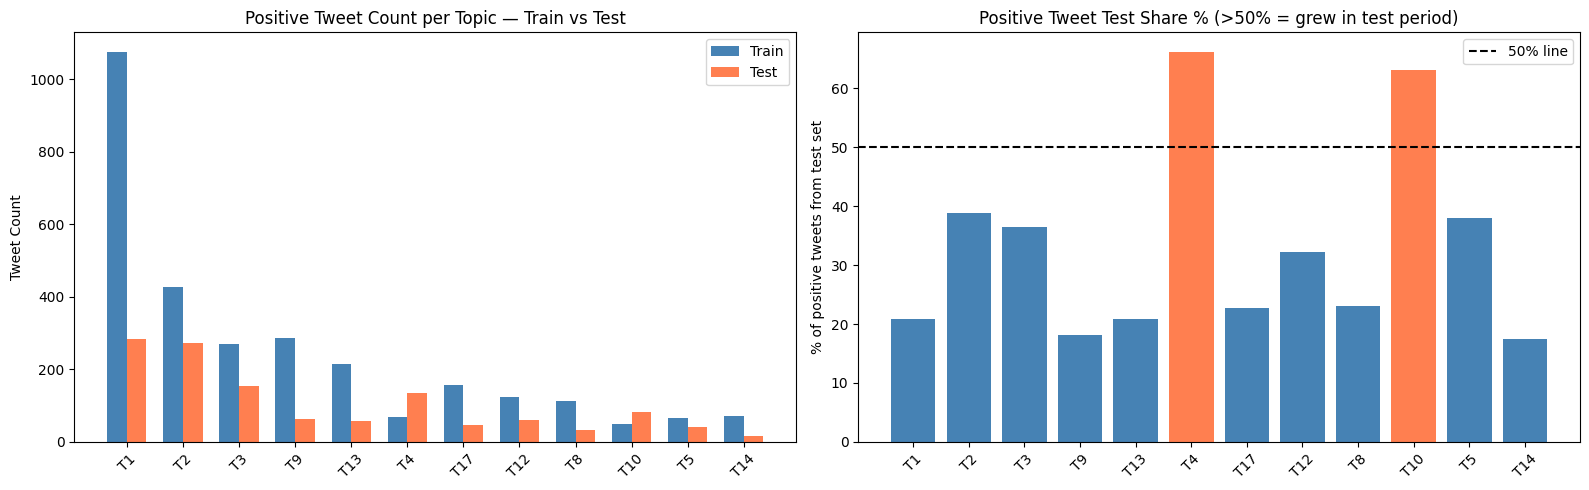

In [ ]:
# ── CELL: Visualise — train vs test positive tweet counts per topic ──
pos_top_topics = pos_topic_comparison.head(12)  # top 12 biggest topics

x      = range(len(pos_top_topics))
width  = 0.35
labels = [f"T{tid+1}" for tid in pos_top_topics.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw counts
axes[0].bar([i - width/2 for i in x], pos_top_topics['train_count'],
            width, label='Train', color='steelblue')
axes[0].bar([i + width/2 for i in x], pos_top_topics['test_count'],
            width, label='Test',  color='coral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_title("Positive Tweet Count per Topic — Train vs Test")
axes[0].set_ylabel("Tweet Count")
axes[0].legend()

# Right: test share %
axes[1].bar(labels, pos_top_topics['test_share'], color=[
    'coral' if v > 60 else 'steelblue' for v in pos_top_topics['test_share']
])
axes[1].axhline(50, linestyle='--', color='black', label='50% line')
axes[1].set_title("Positive Tweet Test Share % (>50% = grew in test period)")
axes[1].set_ylabel("% of positive tweets from test set")
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── CELL: Positive sentiment shift visualisation ─────────────
# Topics where positive tweets grew in the test period

pos_grew = pos_overlap_df[pos_overlap_df['test_count'] > pos_overlap_df['train_count']].copy()
pos_grew = pos_grew.sort_values('test_count', ascending=False)

print(f"\nTopics where POSITIVE tweets GREW in the test period ({len(pos_grew)} topics):")
print(pos_grew[['top_words', 'train_count', 'test_count',
                'train_pos', 'test_pos', 'pos_shift']].to_string(index=False))


Topics where POSITIVE tweets GREW in the test period (6 topics):
                                             top_words  train_count  test_count  train_pos  test_pos  pos_shift
                   3g, 3gs, iphone, iphone 3g, upgrade           69         135      0.324     0.169     -0.155
                   squarespace, win, card, iphone, soo           48          82      0.436     0.294     -0.142
                     30, os 30, os, iphone os, upgrade           10          37      0.233     0.117     -0.116
update, iphone update, updating, iphone, update iphone           21          32      0.223     0.078     -0.145
                   jailbreak, 30, apps, able, download            7          23      0.179     0.111     -0.068
           30, iphone 30, update, 30 update, iphone os            7          19      0.583     0.084     -0.499


In [ ]:
# ── CELL: Final positive-tweet novelty summary ───────────────
pos_novel_topics = pos_topic_comparison[pos_topic_comparison['test_share'] > 60].copy()
pos_novel_topics = pos_novel_topics.sort_values('test_share', ascending=False)

print("NOVEL TOPICS (POSITIVE) — emerged or exploded after June 15 cutoff")
print("=" * 70)
for tid, row in pos_novel_topics.iterrows():
    pos_shift_vals = pos_overlap_df[pos_overlap_df['topic_id'] == tid]['pos_shift'].values
    shift_str = (f"{pos_shift_vals[0]:+.2f} — positive sentiment "
             f"{'increased' if pos_shift_vals[0] > 0 else 'declined'}") \
             if len(pos_shift_vals) > 0 else "N/A — no training tweets (purely emergent)"
    print(f"  Topic {tid+1}: {row['top_words']}")
    print(f"    {row['train_count']} train → {row['test_count']} test positive tweets "
          f"({row['test_share']}% in test)  |  sentiment shift: {shift_str}")
    print()

NOVEL TOPICS (POSITIVE) — emerged or exploded after June 15 cutoff
  Topic 7: 30, os 30, os, iphone os, upgrade
    10 train → 37 test positive tweets (78.7% in test)  |  sentiment shift: -0.12 — positive sentiment declined

  Topic 11: jailbreak, 30, apps, able, download
    7 train → 23 test positive tweets (76.7% in test)  |  sentiment shift: -0.07 — positive sentiment declined

  Topic 15: 30, iphone 30, update, 30 update, iphone os
    7 train → 19 test positive tweets (73.1% in test)  |  sentiment shift: -0.50 — positive sentiment declined

  Topic 4: 3g, 3gs, iphone, iphone 3g, upgrade
    69 train → 135 test positive tweets (66.2% in test)  |  sentiment shift: -0.15 — positive sentiment declined

  Topic 10: squarespace, win, card, iphone, soo
    48 train → 82 test positive tweets (63.1% in test)  |  sentiment shift: -0.14 — positive sentiment declined

  Topic 6: update, iphone update, updating, iphone, update iphone
    21 train → 32 test positive tweets (60.4% in test)  |  